In [7]:
import urllib.request
import datetime
import json
import pandas as pd

ServiceKey= "여기에_발급받은_인증키를_입력하세요"
import urllib.parse

In [8]:
def getRequestUrl(url):
    req = urllib.request.Request(url)
    try:
        response  = urllib.request.urlopen(req)
        if response.getcode() == 200:
            print ("[%s] Url Request Success" % datetime.datetime.now())
            return response.read().decode('utf-8')
        
        return None
    except Exception as e:
        print(e)
        print("[%s] Error for URL: %s" % (datetime.datetime.now(), url))
        return None

In [9]:
def reqAirInfo(where, beginDay, endDay, numOfRows):
    service_url = 'http://apis.data.go.kr/B552584/ArpltnStatsSvc/getMsrstnAcctoRDyrg'
    parameters = "?returnType=json&serviceKey=" + ServiceKey # 인증키
    parameters += "&msrstnName=" + (urllib.parse.quote(where))
    parameters += "&inqBginDt=" + beginDay
    parameters += "&inqEndDt=" + endDay
    parameters += "&numOfRows=" + numOfRows
    url = service_url + parameters
    print(url) # 액세스 거부 여부 확인용 완성된 url출력
    
    responseDecode = getRequestUrl(url)
    if (responseDecode == None):
        return None
    else:
        return json.loads(responseDecode)

In [10]:
def getAirInfoItem(item, result):
    msrstnName = item['msrstnName'] # 측정소
    msurDt = item['msurDt'] #측정일
    so2Value = item['so2Value'] # 아황산가스 평균 농도
    coValue  = item['coValue'] #일산화탄소 평균 농도
    o3Value  = item['o3Value'] # 오존 평균농도
    no2Value  = item['no2Value'] # 이산화질소 평균 농도
    pm10Value  = item['pm10Value'] # 미세먼지 평균 농도
    pm25Value  = item['pm25Value'] # 초미세먼지 평균 농도
    
    result.append([msrstnName, msurDt, so2Value, coValue, o3Value, no2Value, pm10Value, pm25Value])

In [11]:
where = input('대기오염 데이터 수집 측정소를 입력하세요: ')
beginDay = input('대기오염 데이터 수집 시작 일자를 입력하세요(YYYYMMDD):')
endDay  = input('대기오염 데이터 수집 종료 일자를 입력하세요(YYYYMMDD):')

In [12]:
b_date  = datetime.datetime.strptime(beginDay, '%Y%m%d')
e_date = datetime.datetime.strptime(endDay, '%Y%m%d')

In [13]:
days=e_date - b_date
numOfRows = str(days.days) #크롤링 데이터 수: 수집 기간의 일수
jsonResponse =[] # 크롤링한 JSON 데이터를 저장할 리스트
result =[] #JSON에서 항목을 추출하여 저장할 리스트 -> Csv로 저장

In [14]:
jsonResponse = reqAirInfo(where, beginDay, endDay, numOfRows) # [CODE 2]

http://apis.data.go.kr/B552584/ArpltnStatsSvc/getMsrstnAcctoRDyrg?returnType=json&serviceKey=여기에_발급받은_인증키를_입력하세요&msrstnName=%EC%A2%85%EB%A1%9C%EA%B5%AC&inqBginDt=20220401&inqEndDt=20240215&numOfRows=685
'ascii' codec can't encode characters in position 75-77: ordinal not in range(128)
[2025-12-02 11:17:15.623300] Error for URL: http://apis.data.go.kr/B552584/ArpltnStatsSvc/getMsrstnAcctoRDyrg?returnType=json&serviceKey=여기에_발급받은_인증키를_입력하세요&msrstnName=%EC%A2%85%EB%A1%9C%EA%B5%AC&inqBginDt=20220401&inqEndDt=20240215&numOfRows=685


In [15]:
for item in jsonResponse['response']['body']['items']:
    getAirInfoItem(item, result) # [CODE 3]

TypeError: 'NoneType' object is not subscriptable

In [16]:
columnNames = ["location", "day", "so2", "co", "o3", "no2", "pm10", "pm25"]
result_df = pd.DataFrame (result, columns = columnNames)
result_df.to_csv('./10장_data/대기오염데이터_%s_%s_%s.csv' % (where, beginDay, endDay), index=False, encoding ='CP949')

print('./10장_data/대기오염데이터_%s_%s_%s.csv 저장완료.' % (where, beginDay, endDay))

OSError: Cannot save file into a non-existent directory: '10장_data'

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # 추가된 import

In [19]:
data_df = pd.read_csv('대기오염데이터_종로구_20220401_20240215.csv', header=0, encoding='CP949', engine='python')

In [20]:
print(data_df.shape)

(673, 8)


In [21]:
data_df.isna().sum()

location    0
day         0
so2         7
co          0
o3          0
no2         0
pm10        0
pm25        0
dtype: int64

In [22]:
data_df = data_df.fillna(data_df['so2'].median())
data_df.isna().sum() #작업 결과 확인용

location    0
day         0
so2         0
co          0
o3          0
no2         0
pm10        0
pm25        0
dtype: int64

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/Users/solseon/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/solseon/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/solseon/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{H

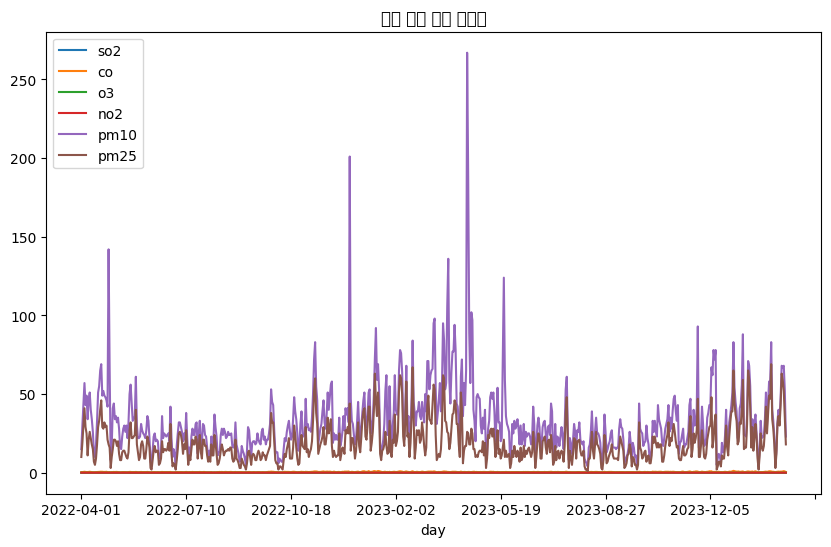

In [23]:
plt.rc('font', family='Malgun Gothic')
graph_df = data_df.drop(['location'], axis = 1, inplace = False)
graph_df.set_index('day', inplace=True)
graph_df.plot(kind='line', figsize=(10, 6)) #kind='line' 선형그래프 지정
plt.title('대기 오염 항목 그래프')
plt.xlabel('day')
plt.legend(loc='upper left') #범례 위치 설정
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
data_df2 = data_df.drop(['location', 'day'], axis = 1, inplace = False)
data_df2_scaled = StandardScaler().fit_transform(data_df2.values)
data_df2 = pd.DataFrame(data_df2_scaled)
data_df2.columns = ['so2', 'co', 'o3', 'no2','pm10','pm25']

In [26]:
day_df = data_df[['day']].copy()
graph_df2 = pd.concat([day_df, data_df2], axis=1)

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/Users/solseon/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/solseon/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/solseon/Library/P

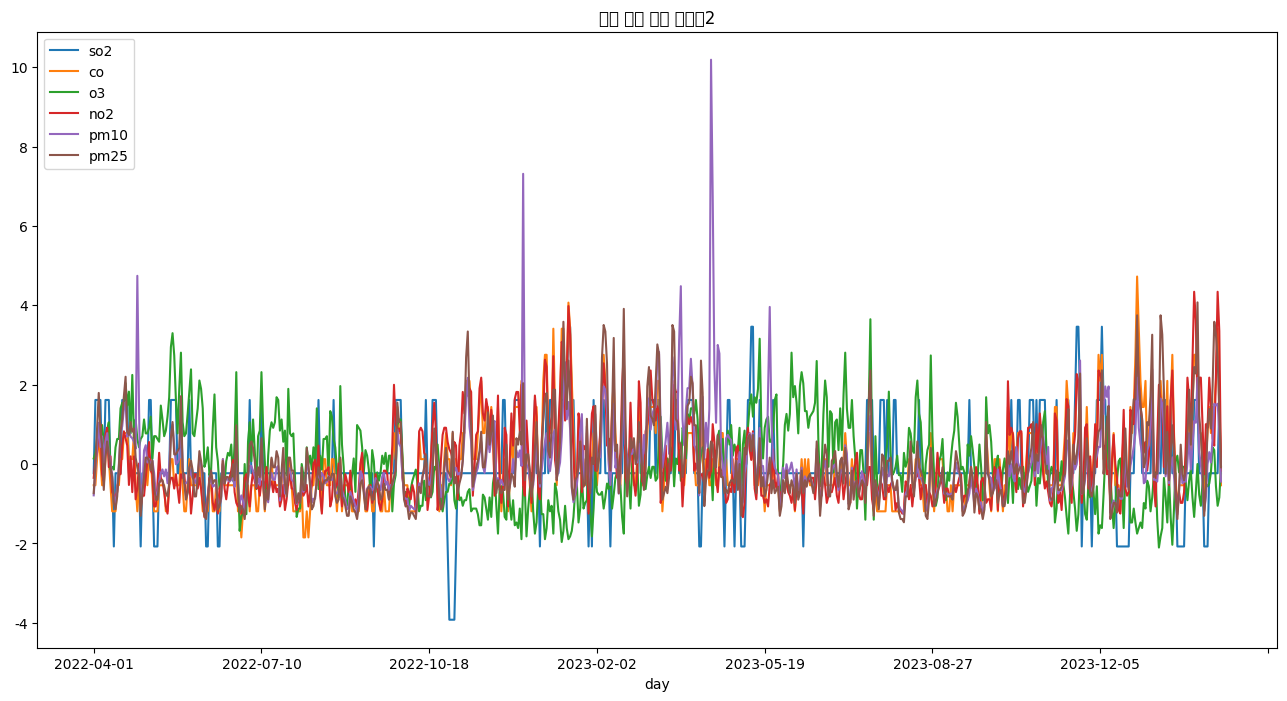

In [27]:
graph_df2.set_index('day', inplace = True)
graph_df2.plot(kind='line', figsize = (16, 8))
plt.title('대기 오염 항목 그래프2')
plt.xlabel('day')
plt.legend(loc = 'upper left')
plt.rcParams['axes.unicode_minus'] = False #음수 부호 깨지지 않게 설정
plt.show()

In [28]:
#X, Y 분할하기
Y_pm10 = data_df['pm10']
# 미세먼지 분석을 위한 Y
Y_pm25 = data_df['pm25']
# 초미세먼지 분석을 위한 Y
X = data_df.drop(['location', 'day','pm10', 'pm25'], axis = 1, inplace  = False)

In [29]:
#훈련 데이터와 평가 데이터 분할하기
X_train, X_test, Y_pm10_train, Y_pm10_test = train_test_split(X, Y_pm10, test_size=0.3, random_state=156)

In [30]:
#선형 회귀 분석: 모델 생성
lr_pm10 = LinearRegression()

In [31]:
#선형 회귀 분석: 모델 훈련
lr_pm10.fit(X_train, Y_pm10_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
#선형 회귀 분석: 평가 데이터에 대한 예측 수행 -> 예측 결과로 Y_predict 구하기
Y_pm10_predict = lr_pm10.predict(X_test)

In [33]:
mse = mean_squared_error(Y_pm10_test, Y_pm10_predict)
rmse = np.sqrt(mse)
print('MSE: {0:.3f}, RMSE: {1:.3f}'.format(mse, rmse))
print('R^2(Variance score): {0:.3f}'.format(r2_score(Y_pm10_test, Y_pm10_predict)))

MSE: 293.367, RMSE: 17.128
R^2(Variance score): 0.344


In [34]:
print('Y_pm10 절편 값: ', lr_pm10.intercept_)
print('회귀 계수 값: ', np.round(lr_pm10.coef_, 1))

Y_pm10 절편 값:  -24.637204220135338
회귀 계수 값:  [2512.8   55.2  444.8  447.3]


In [35]:
coef = pd.Series(data = np.round(lr_pm10.coef_, 2), index = X.columns)
coef.sort_values (ascending = False)

so2    2512.75
no2     447.27
o3      444.80
co       55.18
dtype: float64

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

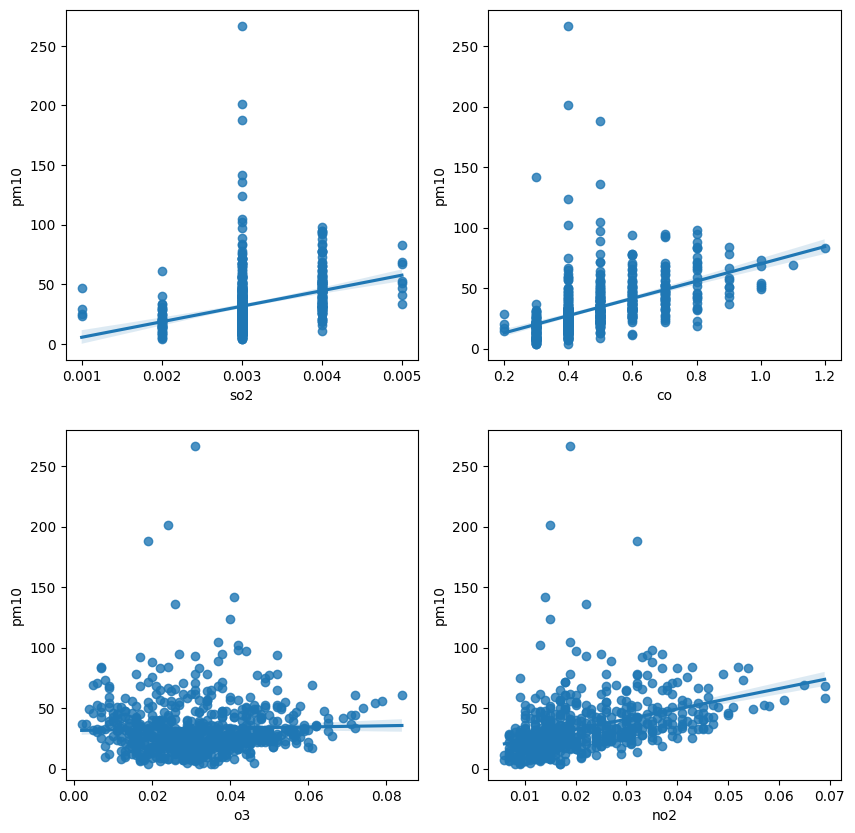

In [36]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
x_features = ['so2', 'co', 'o3', 'no2']
for i, feature in enumerate(x_features):
    row=int(i/2)
    col=i%2
    sns.regplot(x=feature, y='pm10', data = data_df, ax=axs[row][col])
plt.show()

In [37]:
X_train, X_test, Y_pm25_train, Y_pm25_test = train_test_split(X, Y_pm25, test_size=0.3, random_state=156)

In [38]:
lr_pm25 = LinearRegression()

In [39]:
lr_pm25.fit(X_train, Y_pm25_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
Y_pm25_predict = lr_pm25.predict(X_test)

In [41]:
mse = mean_squared_error(Y_pm25_test, Y_pm25_predict)
rmse = np.sqrt(mse)
print('MSE: {0:.3f}, RMSE: {1:.3f}'.format(mse, rmse))
print('R^2(Variance score): {0:.3f}'.format(r2_score(Y_pm25_test, Y_pm25_predict)))

MSE: 51.813, RMSE: 7.198
R^2(Variance score): 0.661


In [42]:
print('Y_pm25 절편 값: ', lr_pm25.intercept_)
print('회귀 계수 값:', np.round(lr_pm25.coef_, 1))

Y_pm25 절편 값:  -22.952459871175382
회귀 계수 값: [776.   61.5 218.2 136.8]


In [43]:
coef = pd.Series(data = np.round(lr_pm25.coef_, 2), index = X.columns)
coef.sort_values (ascending = False)

so2    776.01
o3     218.18
no2    136.83
co      61.50
dtype: float64

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

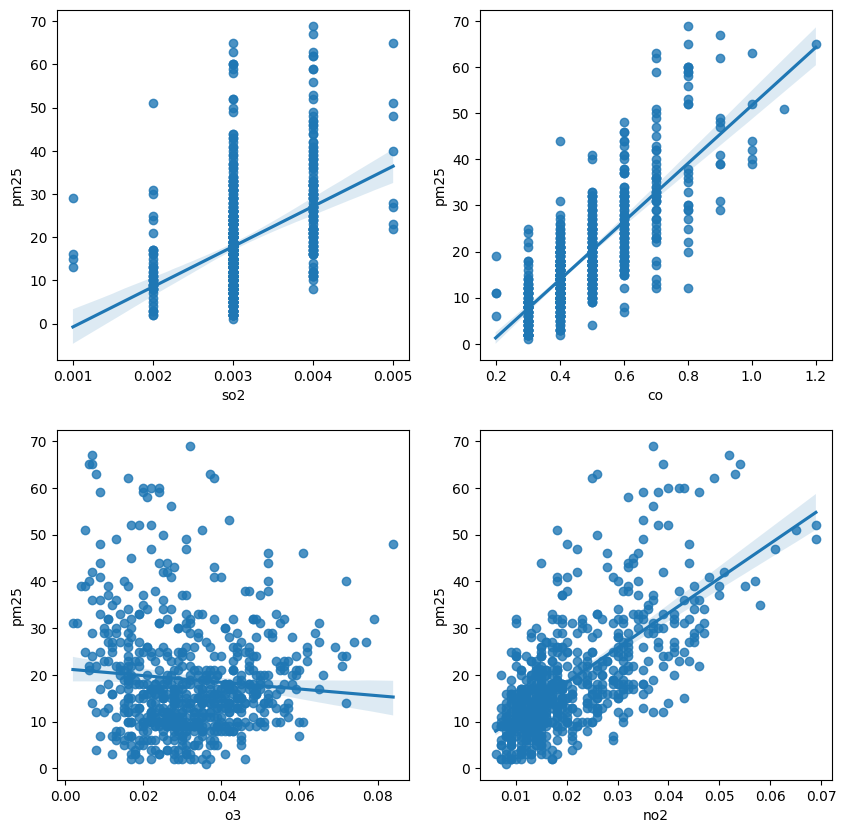

In [44]:
fig, axs  = plt.subplots(figsize = (10, 10), ncols = 2, nrows=2)
x_features = ['so2', 'co', 'o3', 'no2']
for i, feature in enumerate(x_features):
    row=int(i/2)
    col=i%2
    sns.regplot(x = feature, y='pm25', data = data_df, ax=axs[row][col])
plt.show()